# DNN & CNN for CIFAR-10

In [11]:
import numpy as np
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from tensorflow.keras import Model


In [12]:
def plot_loss_accuracy(history):
    # Plot training and validation loss
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [13]:
def visualize_predictions(model, x_test):
    
    # Predict labels for test set
    y_pred = model.predict(x_test)
    predicted_labels = np.argmax(y_pred, axis=1)

    # Define class names for CIFAR-10 dataset
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

    # Visualize some examples
    plt.figure(figsize=(10, 10))
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.imshow(x_test[i])
        true_label = class_names[np.argmax(y_test[i])]
        pred_label = class_names[predicted_labels[i]]
        plt.title(f'True: {true_label}\nPred: {pred_label}')
        plt.axis('off')
        plt.subplots_adjust(wspace=1)

    plt.show()

In [14]:
def plot_samples_per_class(y):

    # Define class names for CIFAR-10 dataset
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

    # Count the number of samples per class
    class_counts = np.zeros(10, dtype=int)
    for i in range(10):
        class_counts[i] = np.sum(y == i)

    # Plot the number of samples per class
    plt.figure(figsize=(10, 5))
    plt.bar(class_names, class_counts)
    plt.xlabel('Class')
    plt.ylabel('Number of Samples')
    plt.xticks(rotation=45, ha='right')
    plt.show()


In [15]:
def plot_confusion_matrix(model, x_test):
    # Predict labels for test set
    y_pred = model.predict(x_test)
    predicted_labels = np.argmax(y_pred, axis=1)
    true_labels = np.argmax(y_test, axis=1)

    # Compute confusion matrix
    conf_matrix = confusion_matrix(true_labels, predicted_labels)

    # Plot confusion matrix with numbers
    plt.figure(figsize=(10, 8))
    plt.imshow(conf_matrix, cmap=plt.cm.Blues)

    # Add numbers to the plot
    thresh = conf_matrix.max() / 2
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, format(conf_matrix[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if conf_matrix[i, j] > thresh else "black")

    plt.colorbar()
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(np.arange(10), class_names, rotation=45)
    plt.yticks(np.arange(10), class_names)
    plt.tight_layout()
    plt.show()


In [16]:
def show_filters(model, layer_indx, num_filters):
    # Get the weights of the first convolutional layer
    filters = model.layers[layer_indx].get_weights()[0]

    # Normalize filter values to range [0, 1] for visualization
    filters = (filters - filters.min()) / (filters.max() - filters.min())

    # Plot the filters
    plt.figure(figsize=(8, 8))
    for i in range(num_filters):  # assuming 32 filters in the first convolutional layer
        plt.subplot(8, 4, i + 1)
        plt.imshow(filters[:, :, :, i], cmap='gray')
        plt.axis('off')
    plt.show()

In [17]:
def show_feature_maps(model, x_test):
    # Extract feature maps from the first convolutional layer
    feature_map_model = Model(inputs=model.inputs, outputs=model.layers[0].output)
    feature_maps = feature_map_model.predict(x_test)

    # Choose a random image index
    random_index = np.random.randint(0, len(x_test))

    # Plot the original image
    plt.figure(figsize=(3, 3))
    plt.imshow(x_test[random_index])
    plt.title('Original Image')
    plt.axis('off')
    plt.show()

    # Plot the feature maps
    plt.figure(figsize=(12, 6))
    num_feature_maps = feature_maps.shape[-1]
    for i in range(num_feature_maps):
        plt.subplot(4, 8, i + 1)
        plt.imshow(feature_maps[random_index, :, :, i])
        plt.axis('off')

    plt.suptitle('Feature Maps')
    plt.show()

In [18]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

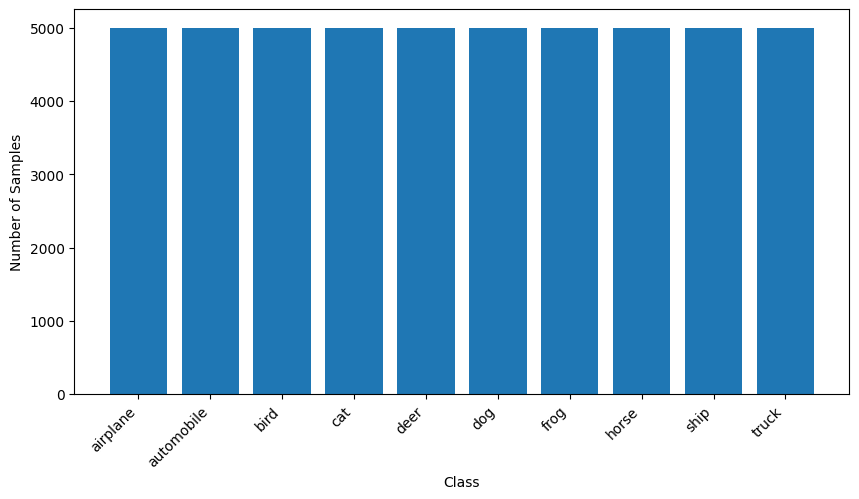

In [19]:
plot_samples_per_class(y_train)

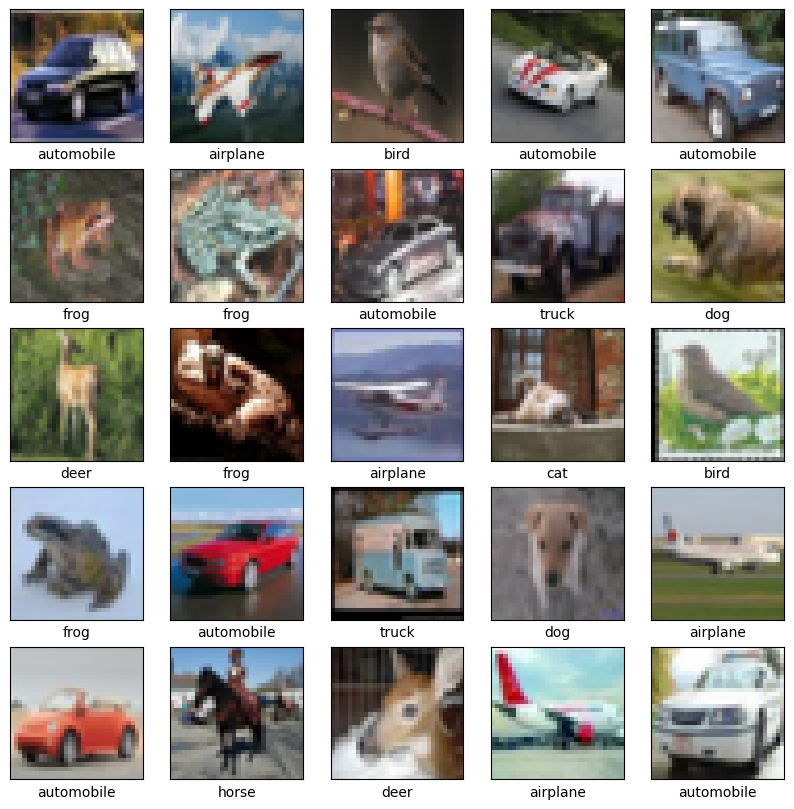

In [20]:
# Define class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Plot some random examples
plt.figure(figsize=(10, 10))
for i in range(25):
    index = np.random.randint(0, X_train.shape[0])
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[index], cmap=plt.cm.binary)
    plt.xlabel(class_names[int(y_train[index])])
plt.show()


In [21]:
# Normalize pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0


In [22]:
X_train.shape

(50000, 32, 32, 3)

In [23]:
X_test.shape

(10000, 32, 32, 3)

In [24]:
round(100*X_test.shape[0]/(X_train.shape[0] + X_test.shape[0]),2)

16.67

In [25]:
# One-hot encode the target labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# DNN

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_5 (Flatten)         (None, 3072)              0         
                                                                 
 dense_22 (Dense)            (None, 512)               1573376   
                                                                 
 dense_23 (Dense)            (None, 256)               131328    
                                                                 
 dense_24 (Dense)            (None, 128)               32896     
                                                                 
 dense_25 (Dense)            (None, 64)                8256      
                                                                 
 dense_26 (Dense)            (None, 10)                650       
                                                                 
Total params: 1,746,506
Trainable params: 1,746,506
No

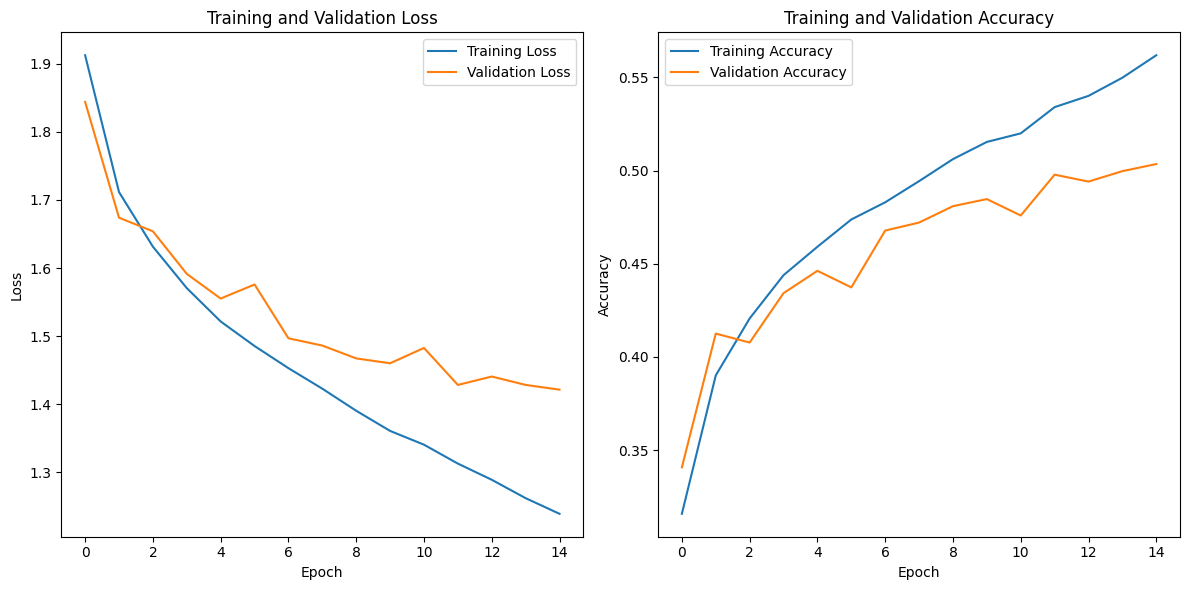

313/313 [==============================] - 1s 2ms/step - loss: 1.3875 - accuracy: 0.5086
DNN Model - Test Accuracy: 0.5085999965667725


In [32]:
# Define the DNN architecture
model_dnn = Sequential()
model_dnn.add(Flatten(input_shape=(32, 32, 3)))
model_dnn.add(Dense(512, activation='relu'))
# model_dnn.add(Dropout(0.5))
model_dnn.add(Dense(256, activation='relu'))
# model_dnn.add(Dropout(0.5))
model_dnn.add(Dense(128, activation='relu'))
model_dnn.add(Dense(64, activation='relu'))

model_dnn.add(Dense(10, activation='softmax'))

# Compile the DNN model
model_dnn.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

model_dnn.summary()

# Train the DNN model
history_dnn = model_dnn.fit(X_train, y_train, epochs=15, batch_size=64, validation_split=0.2)

plot_loss_accuracy(history_dnn)

# Evaluate the DNN model
loss_dnn, accuracy_dnn = model_dnn.evaluate(X_test, y_test)
print("DNN Model - Test Accuracy:", accuracy_dnn)

# CNN

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 30, 30, 64)        1792      
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 15, 15, 64)       0         
 2D)                                                             
                                                                 
 conv2d_13 (Conv2D)          (None, 13, 13, 128)       73856     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 6, 6, 128)        0         
 2D)                                                             
                                                                 
 conv2d_14 (Conv2D)          (None, 4, 4, 128)         147584    
                                                                 
 flatten_10 (Flatten)        (None, 2048)            

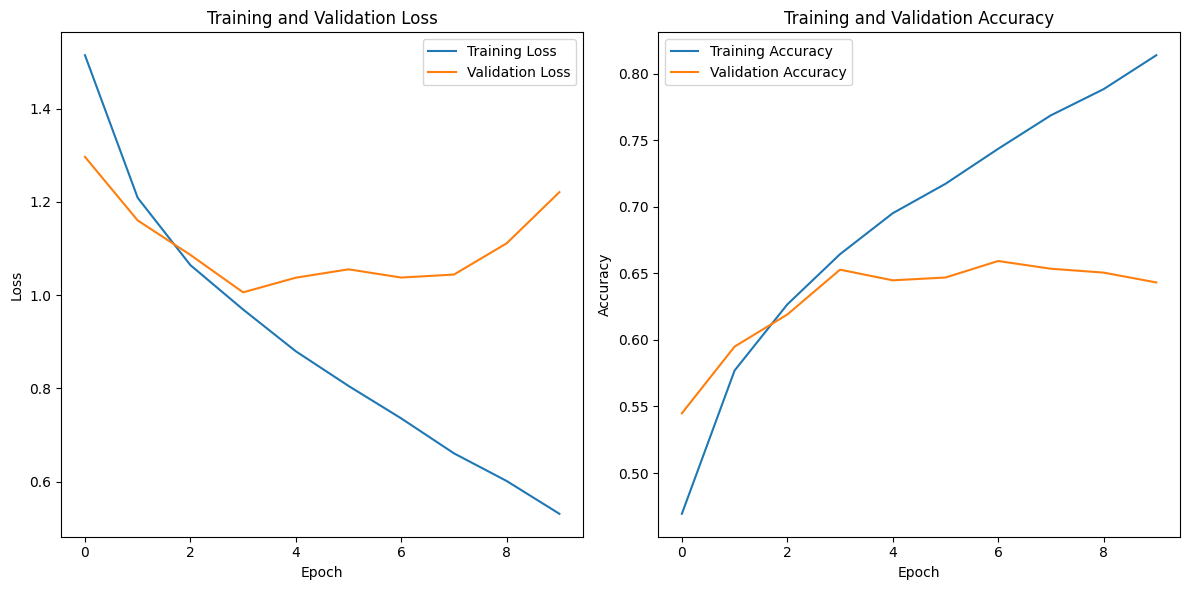

313/313 [==============================] - 1s 2ms/step - loss: 1.2347 - accuracy: 0.6383
CNN Model - Test Accuracy: 0.6383000016212463


In [37]:
# Define the CNN architecture
model_cnn = Sequential()
model_cnn.add(Conv2D(64, (3, 3), activation='selu', input_shape=(32, 32, 3)))
model_cnn.add(MaxPooling2D((2, 2)))

model_cnn.add(Conv2D(128, (3, 3), activation='selu'))
model_cnn.add(MaxPooling2D((2, 2)))

model_cnn.add(Conv2D(128, (3, 3), activation='selu'))
model_cnn.add(Flatten())

model_cnn.add(Dense(64, activation='selu'))
model_cnn.add(Dense(10, activation='softmax'))

# Compile the model
model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_cnn.summary()

# Train the CNN model
history_cnn = model_cnn.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

plot_loss_accuracy(history_cnn)

# Evaluate the CNN model
loss_cnn, accuracy_cnn = model_cnn.evaluate(X_test, y_test)
print("CNN Model - Test Accuracy:", accuracy_cnn)

313/313 [==============================] - 1s 2ms/step


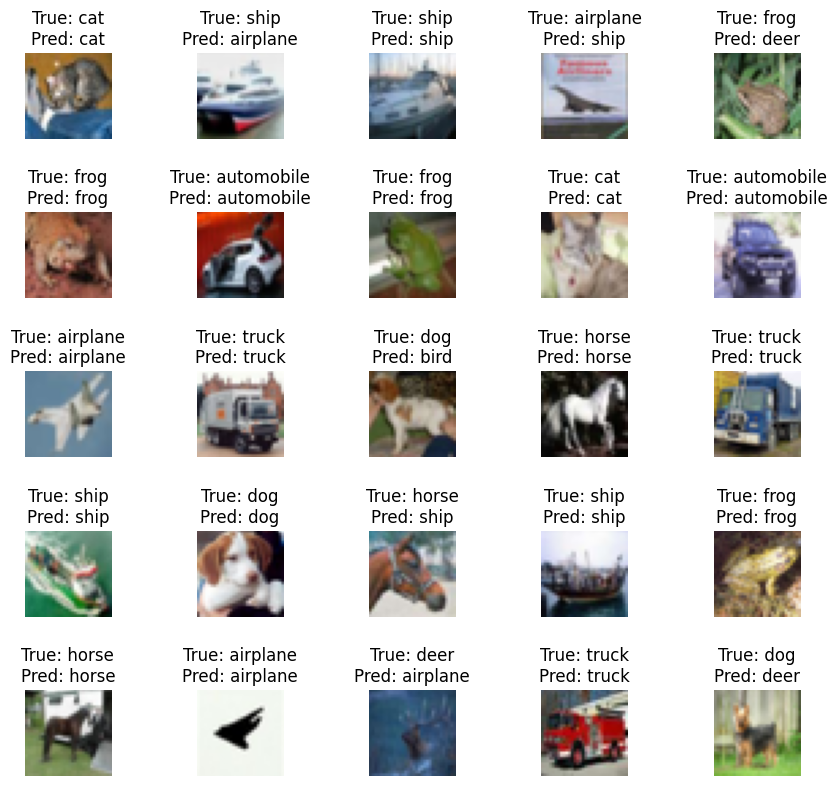

In [38]:
visualize_predictions(model_cnn, X_test)

313/313 [==============================] - 1s 2ms/step


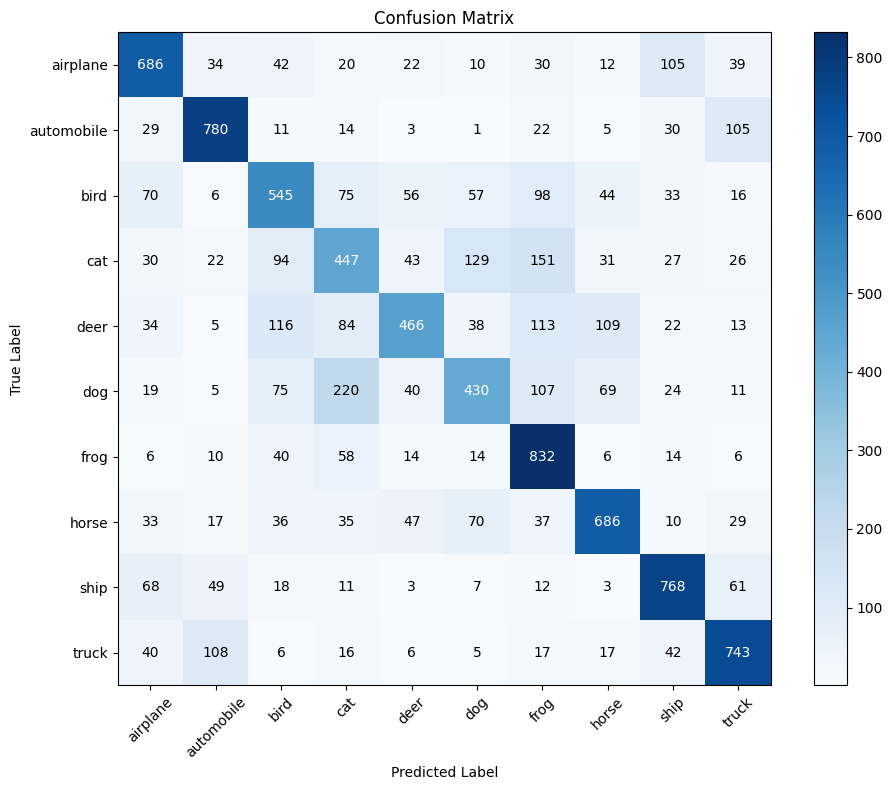

In [39]:
plot_confusion_matrix(model_cnn, X_test)

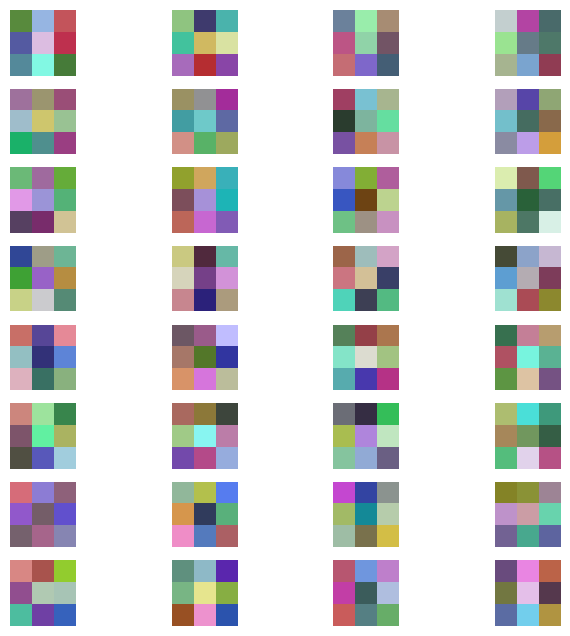

In [40]:
show_filters(model_cnn, 0, 32)

313/313 [==============================] - 0s 1ms/step


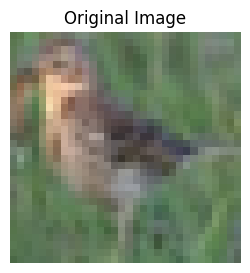

ValueError: num must be an integer with 1 <= num <= 32, not 33

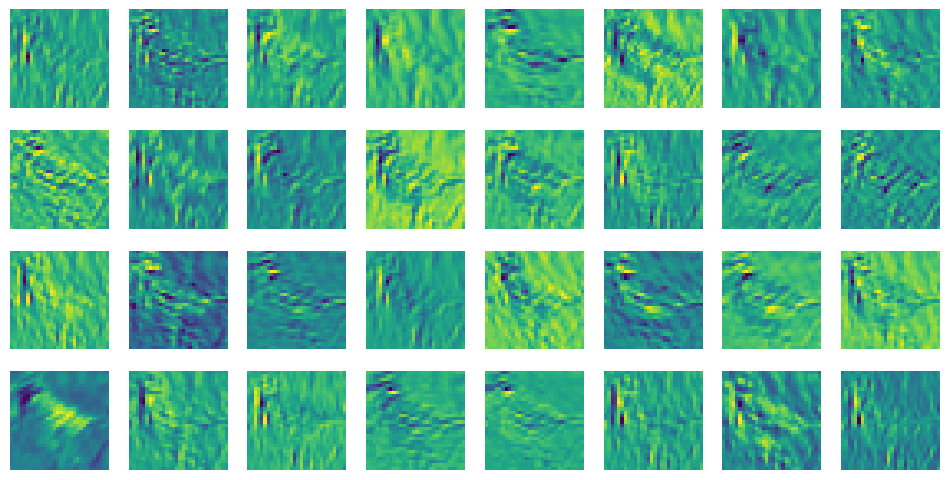

In [41]:
show_feature_maps(model_cnn, X_test)